In [1]:
# This code loads a particular model from the saved models.
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from torch.linalg import eigvalsh
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.linalg import eigvals as scipy_eigvals



num_iter = 10000

torch.backends.cudnn.enabled = False
dtype = torch.float64
torch.set_default_dtype(dtype)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device: ", device)

# Parameters

Nc = 3
g5_sq = (12*np.pi**2)/Nc

omega_a1 = torch.tensor([1.23, 1.655], device=device)  # in GeV
omega_a2 = torch.tensor([1.3182, 1.706], device=device)  # in GeV
omega_rho = torch.tensor([0.77526, 1.465, 1.72], device=device)
omega_f0 = torch.tensor([0.475, 0.99, torch.nan, 1.522, 1.733, 1.982], device=device)  # in GeV
omega_pi = torch.tensor([0.134, 1.3, 1.8], device=device)  # in GeV

z_max = 15.0
h = 0.15
z_ini = h

def V_k_fn(v_z, k1, k2):
    return (k2)*v_z**3 + k1*v_z**2

fpi_sq = (92.4e-3)**2  # in GeV^2
mpi_sq = (139.57e-3)**2  # in GeV^2

zeta = np.sqrt(Nc)/(2*np.pi)

def Sigma_fn(theta, scale=1):
    return 0.01 + (0.03 - 0.01)*torch.sigmoid(theta*scale)

def ab_fn(theta, L):
    Sigma = Sigma_fn(theta)
    m_q = fpi_sq*mpi_sq/(2*Sigma)
    alpha = zeta*m_q*L
    beta = (Sigma/zeta)*(L**3)

    return alpha, beta

# DEFINE A(z) THE NEURAL NETWORK
n_neurons = [50, 50, 50, 50]

class A_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [-1, 1]
        #z = 2.0 * (z) / (z_max) - 1.0

        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()


# DEFINE v(z)THE NEURAL NETWORK
#n_neurons = [20, 20, 20, 20] # number of neurons in each hidden layer

class v_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()
    
def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        #torch.nn.init.xavier_normal_(m.weight)

def v_z_fn(z, model_v, theta, L):
    alpha, beta = ab_fn(theta, L)
    return (alpha*z + beta*z**3 + model_v(z)*z**4)/(1+z**3)

def A_z_fn(z, model_A):
    return -torch.log(z) + z*model_A(z)*0.1

def B2_dash_z_fn(exp_2A_z, v_z, dv_dz, d2v_dz2, k1, k2):
    return (d2v_dz2 - exp_2A_z*(-3*v_z - V_k_fn(v_z, k1, k2)))/dv_dz


def V_mesons(model_A, model_v,  k1, k2, theta, L, z=None):
    if z is None:
        z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]
    
    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2,  k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    d2B2_dz2 = autograd.grad(dB2_dz, z, torch.ones_like(dB2_dz), create_graph=True)[0]
    d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

    V_rho = 0.25*dB1_dz**2 - 0.5*d2B1_dz2
    V_a1 = V_rho + g5_sq*exp_2A*v_z**2
    V_a2 = 0.25*dB2_dz**2 - 0.5*d2B2_dz2
    V_f0 = V_a2 + exp_2A*(-3 - (2*k1*v_z + 3*(k2)*v_z**2)) 

    return V_rho, V_a1, V_a2, V_f0

def eigenvalues_square_fn(model_A, model_v,  k1, k2, theta, L, no_eigenvalues = (2, 2, 2, 2)):
    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L)
    diag_elem_rho = 2 + V_rho*h**2
    diag_elem_a1 = 2 + V_a1*h**2
    diag_elem_a2 = 2 + V_a2*h**2
    diag_elem_f0 = 2 + V_f0*h**2

    off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

    mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a1 = (torch.diag(diag_elem_a1) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a2 = (torch.diag(diag_elem_a2) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_f0 = (torch.diag(diag_elem_f0) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2

    eigenvalues_rho = eigvalsh(mat_rho)[:no_eigenvalues[0]]/(L**2)
    eigenvalues_a1 = eigvalsh(mat_a1)[:no_eigenvalues[1]]/(L**2)
    eigenvalues_a2 = eigvalsh(mat_a2)[:no_eigenvalues[2]]/(L**2)
    eigenvalues_f0 = eigvalsh(mat_f0)[:no_eigenvalues[3]]/(L**2)

    return eigenvalues_rho, eigenvalues_a1, eigenvalues_a2, eigenvalues_f0

################################################################################################################################
################################################ Loss Functions ################################################################
################################################################################################################################

# Mass loss
def mass_loss_fn(model_A, model_v,  k1, k2, theta, L, train_data=(omega_rho, omega_a1, omega_a2, omega_f0)):
    omega_rho, omega_a1, omega_a2, omega_f0 = train_data

    mbyL_rho, mbyL_a1, mbyL_a2, mbyL_f0 = eigenvalues_square_fn(model_A, model_v, k1, k2, theta, L, (len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0)))
    
    # remove None values from omega_f0, omega_rho, omega_a1, omega_a2 and corresponding mbyL_f0, mbyL_rho, mbyL_a1, mbyL_a2 values
    mask_f0 = ~torch.isnan(omega_f0)
    mask_rho = ~torch.isnan(omega_rho)
    mask_a1 = ~torch.isnan(omega_a1)
    mask_a2 = ~torch.isnan(omega_a2)


    omega_f0 = omega_f0[mask_f0]
    omega_rho = omega_rho[mask_rho]
    omega_a1 = omega_a1[mask_a1]
    omega_a2 = omega_a2[mask_a2]

    mbyL_f0 = mbyL_f0[mask_f0]
    mbyL_rho = mbyL_rho[mask_rho]
    mbyL_a1 = mbyL_a1[mask_a1]
    mbyL_a2 = mbyL_a2[mask_a2]

    rho_mass_loss = torch.abs(mbyL_rho - omega_rho**2)/omega_rho**2
    a1_mass_loss = torch.abs(mbyL_a1 - omega_a1**2)/omega_a1**2
    a2_mass_loss = torch.abs(mbyL_a2 - omega_a2**2)/omega_a2**2
    f0_mass_loss = torch.abs(mbyL_f0 - omega_f0**2)/omega_f0**2

    f0_mass_loss[0] *= 0.1 # give less weight to the lightest f0 meson since its nature is not well established

    sum_loss = (rho_mass_loss.sum() + a1_mass_loss.sum() + a2_mass_loss.sum() + f0_mass_loss.sum()).detach()

    rho_scaling = rho_mass_loss.detach()/sum_loss
    a1_scaling = a1_mass_loss.detach()/sum_loss
    a2_scaling = a2_mass_loss.detach()/sum_loss
    f0_scaling = f0_mass_loss.detach()/sum_loss

    rho_mass_loss = (rho_mass_loss * rho_scaling).mean()
    a1_mass_loss = (a1_mass_loss * a1_scaling).mean()
    a2_mass_loss = (a2_mass_loss * a2_scaling).mean()
    f0_mass_loss = (f0_mass_loss * f0_scaling).mean()

    return rho_mass_loss, a1_mass_loss, a2_mass_loss, f0_mass_loss

def pos_v_dash_loss_fn(model_v, theta, L):
    z = torch.rand(100, device=device, requires_grad=True)*z_max
    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    return nn.ReLU()(-dv_dz).sum()

def A_z_IR_loss_fn(model_A):
    z = torch.tensor([z_max], device=device, requires_grad=True)
    A_z = A_z_fn(z, model_A)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    return nn.ReLU()(A_z + torch.log(z)-1.5).sum() + nn.ReLU()(dA_dz).sum()

def pot_dash_IR_loss_fn(model_A, model_v, k1, k2, theta, L): # potential should be increasing at IR
    #z = torch.linspace(z_max*(0.8), z_max, 10, device=device, requires_grad=True)
    z = torch.rand(1, device=device, requires_grad=True)*(z_max*0.2) + z_max*0.8

    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v, k1, k2, theta, L, z)
    V_dash_rho = autograd.grad(V_rho, z, torch.ones_like(V_rho), create_graph=True)[0]
    V_dash_a2 = autograd.grad(V_a2, z, torch.ones_like(V_a2), create_graph=True)[0]
    return nn.ReLU()(-V_dash_rho).sum() + nn.ReLU()(-V_dash_a2).sum()



Using device:  cpu


/home/ritik/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/ritik/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
folder_name = 'saved/0/'

params = {}

with open(folder_name + 'params.txt', 'r') as f:
    for line in f:
        if ':' in line:
            key, value = line.split(':', 1)
            params[key.strip()] = value.strip()

for key, value in params.items():
    print(f"{key}: {value}")

min_loss: 0.005345114779300199
k1: -4.006678089811243
k2: 7.454463896905302
theta: 4.527421317520253
L: 1.2272345365250072


In [3]:
model_A = A_LinearNN().to(device)
model_v = v_LinearNN().to(device)

model_A.load_state_dict(torch.load(folder_name + 'model_A.pth', map_location=device))
model_v.load_state_dict(torch.load(folder_name + 'model_v.pth', map_location=device))

k1 = float(params['k1'])
k2 = float(params['k2'])
theta = torch.tensor(float(params['theta']))
L = float(params['L'])

/tmp/ipykernel_1567912/1428350227.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_A.load_state_dict(torch.load(folder_name + 'model_A.pth', map_location=device))
/

Rho Mass:
n=1: 0.7802 GeV, Exp: 0.7753 GeV
n=2: 1.4511 GeV, Exp: 1.4650 GeV
n=3: 1.7236 GeV, Exp: 1.7200 GeV

A1 Mass:
n=1: 1.2231 GeV, Exp: 1.2300 GeV
n=2: 1.6651 GeV, Exp: 1.6550 GeV

A2 Mass:
n=1: 1.3099 GeV, Exp: 1.3182 GeV
n=2: 1.7009 GeV, Exp: 1.7060 GeV

F0 Mass:
n=1: 0.3954 GeV, Exp: 0.4750 GeV
n=2: 0.9917 GeV, Exp: 0.9900 GeV
n=3: 1.5149 GeV, Exp: nan GeV
n=4: 1.5440 GeV, Exp: 1.5220 GeV
n=5: 1.7360 GeV, Exp: 1.7330 GeV
n=6: 1.9533 GeV, Exp: 1.9820 GeV


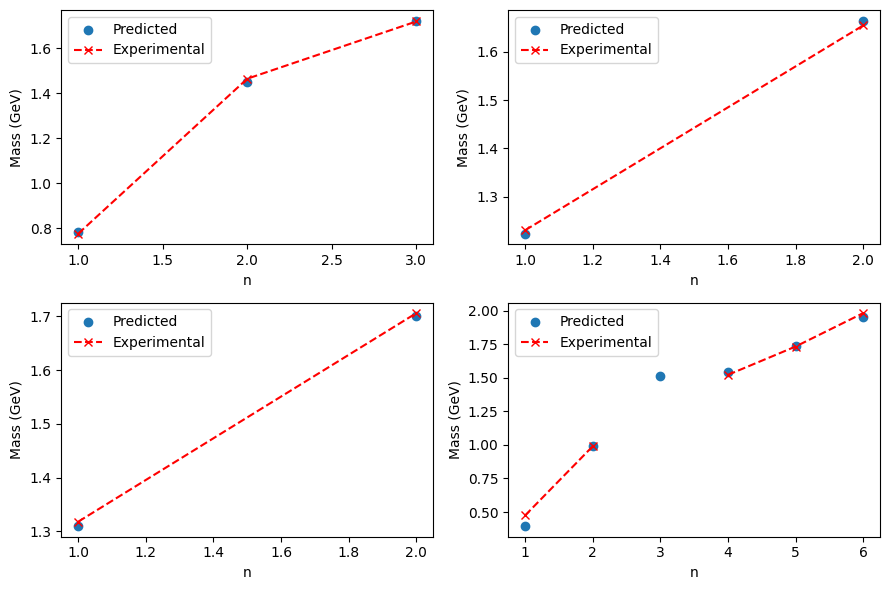

In [4]:
rho_mass, a1_mass, a2_mass, f0_mass = eigenvalues_square_fn(model_A, model_v, k1, k2, theta, L, no_eigenvalues=(len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0)))

rho_mass = rho_mass**(1/2)
a1_mass = a1_mass**(1/2)
a2_mass = a2_mass**(1/2)
f0_mass = f0_mass**(1/2)

print("Rho Mass:")
for i in range(len(omega_rho)):
    print(f"n={i+1}: {rho_mass[i].item():.4f} GeV, Exp: {omega_rho[i].item():.4f} GeV")

print("\nA1 Mass:")
for i in range(len(omega_a1)):
    print(f"n={i+1}: {a1_mass[i].item():.4f} GeV, Exp: {omega_a1[i].item():.4f} GeV")

print("\nA2 Mass:")
for i in range(len(omega_a2)):
    print(f"n={i+1}: {a2_mass[i].item():.4f} GeV, Exp: {omega_a2[i].item():.4f} GeV")

print("\nF0 Mass:")
for i in range(len(omega_f0)):
    print(f"n={i+1}: {f0_mass[i].item():.4f} GeV, Exp: {omega_f0[i].item():.4f} GeV")

fig, axs = plt.subplots(2, 2, figsize=(9, 6))
axs = axs.flatten()

axs[0].scatter(range(1, len(rho_mass)+1), rho_mass.cpu().detach().numpy(), label='Predicted')
axs[0].plot(range(1, len(omega_rho)+1), omega_rho.cpu().detach().numpy(), 'x--', label='Experimental', color="red")

axs[1].scatter(range(1, len(a1_mass)+1), a1_mass.cpu().detach().numpy(), label='Predicted')
axs[1].plot(range(1, len(omega_a1)+1), omega_a1.cpu().detach().numpy(), 'x--', label='Experimental', color="red")

axs[2].scatter(range(1, len(a2_mass)+1), a2_mass.cpu().detach().numpy(), label='Predicted')
axs[2].plot(range(1, len(omega_a2)+1), omega_a2.cpu().detach().numpy(), 'x--', label='Experimental', color="red")

axs[3].scatter(range(1, len(f0_mass)+1), f0_mass.cpu().detach().numpy(), label='Predicted')
axs[3].plot(range(1, len(omega_f0)+1), omega_f0.cpu().detach().numpy(), 'x--', label='Experimental', color="red")

for ax in axs:
    ax.set_xlabel('n')
    ax.set_ylabel('Mass (GeV)')
    ax.legend()
plt.tight_layout()
plt.show()

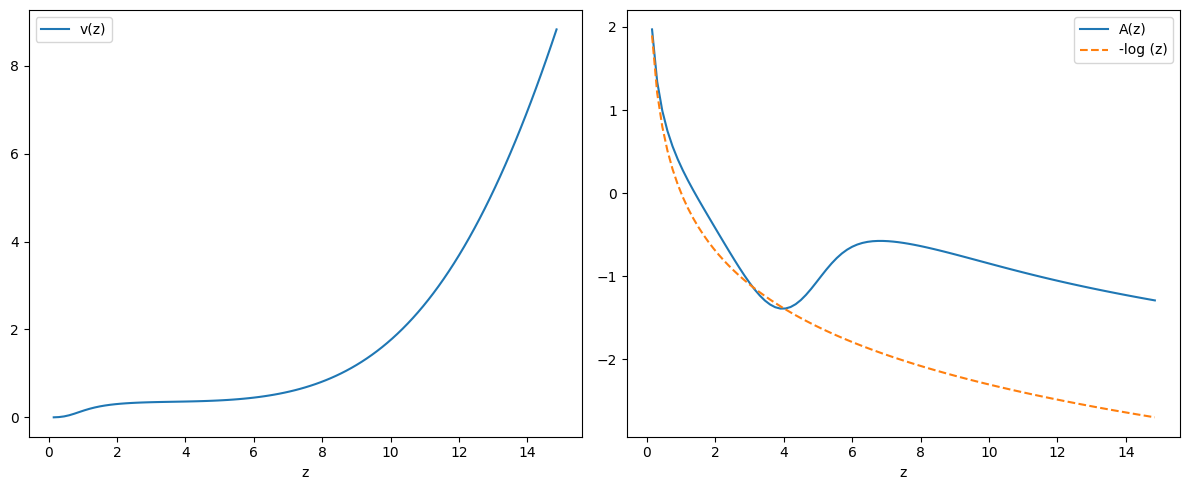

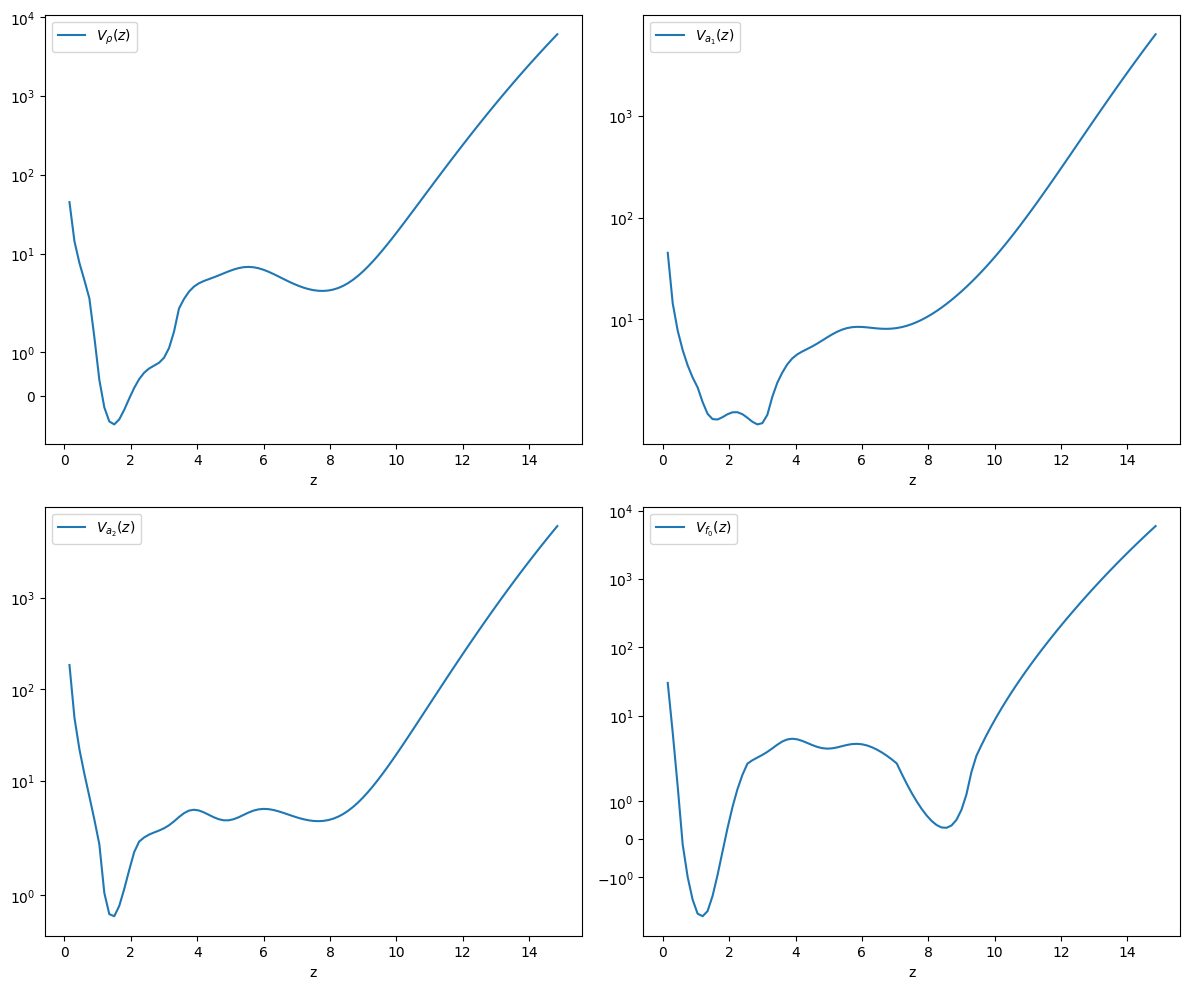

In [5]:
z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

v_z = v_z_fn(z, model_v, theta, L)
A_z = A_z_fn(z, model_A)

V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L, z)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(z.cpu().detach().numpy(), v_z.cpu().detach().numpy(), label='v(z)')
axs[1].plot(z.cpu().detach().numpy(), A_z.cpu().detach().numpy(), label='A(z)')
axs[1].plot(z.cpu().detach().numpy(), -torch.log(z).cpu().detach().numpy(), label='-log (z)', linestyle='--')

for ax in axs:
    ax.set_xlabel('z')
    ax.legend()
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
axs[0].plot(z.cpu().detach().numpy(), V_rho.cpu().detach().numpy(), label='$V_{\\rho}(z)$')
axs[1].plot(z.cpu().detach().numpy(), V_a1.cpu().detach().numpy(), label='$V_{a_1}(z)$')
axs[2].plot(z.cpu().detach().numpy(), V_a2.cpu().detach().numpy(), label='$V_{a_2}(z)$')
axs[3].plot(z.cpu().detach().numpy(), V_f0.cpu().detach().numpy(), label='$V_{f_0}(z)$')

for ax in axs:
    ax.set_xlabel('z')
    ax.legend()
    ax.set_yscale('symlog')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1480625/61148836.py:60: RuntimeWarning: invalid value encountered in sqrt
  pi_mass = np.sqrt(eigenvalues_pi)


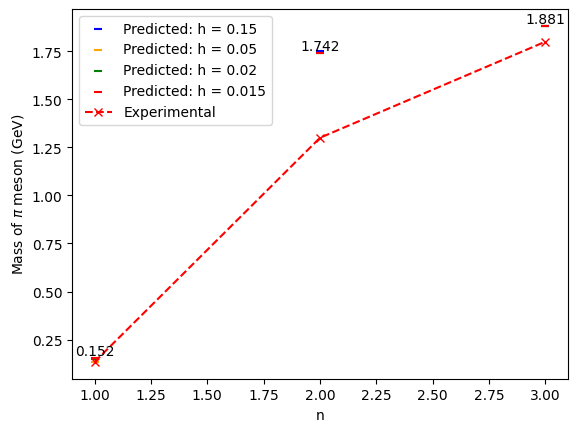

In [6]:
dz_list = [0.15, 0.05, 0.02, 0.015]
color_list = ['blue', 'orange', 'green', 'red', 'gray', 'black']

for i in range(len(dz_list)):

    dz = dz_list[i]
    z = torch.arange(dz, z_max, dz, device=device, requires_grad=True)

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    omega_z = 2*dv_dz/v_z - dB2_dz
    C_z = g5_sq*exp_2A*v_z**2

    # making M1 matrix
    diag_elem_M1 = -2/dz**2 * torch.ones_like(z)
    off_diag_elem_M1_plus = 1/dz**2 + omega_z[:-1]/(2*dz)
    off_diag_elem_M1_minus = 1/dz**2 - omega_z[1:]/(2*dz)
    M1 = torch.diag(diag_elem_M1) + torch.diag(off_diag_elem_M1_plus, diagonal=1) + torch.diag(off_diag_elem_M1_minus, diagonal=-1)

    M1[-1, -1] += 1/dz**2 + omega_z[-1]/(2*dz) # Neumann BC at IR

    # making M2 matrix
    M2 = torch.diag(C_z)

    # making M3 matrix
    diag_elem_M3 = -2/dz**2 - C_z
    off_diag_elem_M3_plus = 1/dz**2 - dB1_dz[:-1]/(2*dz)
    off_diag_elem_M3_minus = 1/dz**2 + dB1_dz[1:]/(2*dz)
    M3 = torch.diag(diag_elem_M3) + torch.diag(off_diag_elem_M3_plus, diagonal=1) + torch.diag(off_diag_elem_M3_minus, diagonal=-1)

    M3[-1, -1] += 1/dz**2 - dB1_dz[-1]/(2*dz) # Neumann BC IR

    M = torch.zeros((2*len(z), 2*len(z)), device=device)
    M[:len(z), :len(z)] = M1
    M[len(z):, :len(z)] = M2
    M[len(z):, len(z):] = M3

    # make T = [[-1, 1], [0, 0]]
    T = torch.zeros((2*len(z), 2*len(z)), device=device)
    T[:len(z), :len(z)] = -1*torch.eye(len(z))
    T[:len(z), len(z):] = torch.eye(len(z))

    M = M.cpu().detach().numpy()
    T = T.cpu().detach().numpy()

    # solve generalized eigenvalue problem using scipy
    eigenvalues_pi = scipy_eigvals(M, T)
    # sort eigenvalues
    eigenvalues_pi = np.sort(eigenvalues_pi.real)
    eigenvalues_pi = eigenvalues_pi[:len(omega_pi)]/(L**2)
    pi_mass = np.sqrt(eigenvalues_pi)

    plt.scatter(range(1, len(pi_mass)+1), pi_mass, label=f'Predicted: h = {dz_list[i]}', marker="_", color=color_list[i])
plt.plot(range(1, len(omega_pi)+1), omega_pi.cpu().detach().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed')
for i in range(len(pi_mass)):
    plt.text(i+1, pi_mass[i].item(), f"{pi_mass[i].item():.3f}", ha='center', va='bottom')
plt.xlabel("n")
plt.ylabel("Mass of $\\pi$ meson (GeV)")
plt.legend()
plt.show()

Predicted Rho Masses (GeV): 
n=1: 0.780 GeV, Error: 0.6 %
n=2: 1.451 GeV, Error: 0.9 %
n=3: 1.724 GeV, Error: 0.2 %
n=4: 1.940 GeV, Error: 2.1 %
n=5: 2.095 GeV, Error: 2.6 %


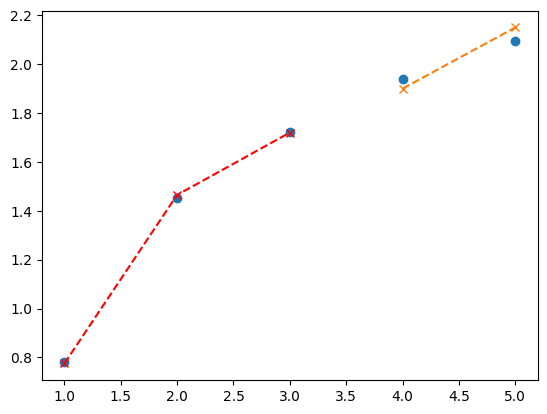

In [7]:
rho_eigval, _, _, _ = eigenvalues_square_fn(model_A, model_v,  k1, k2, theta, L, (len(omega_rho)+2, len(omega_a1), len(omega_a2), len(omega_f0)))
mass_rho = torch.sqrt(rho_eigval)
print("Predicted Rho Masses (GeV): ")
for i in range(len(omega_rho)):
    print(f"n={i+1}: {mass_rho[i].item():.3f} GeV, Error: {(100*torch.abs(mass_rho[i] - omega_rho[i])/omega_rho[i]).item():.1f} %")
print(f"n={len(omega_rho)+1}: {mass_rho[-2].item():.3f} GeV, Error: {(100*torch.abs(mass_rho[-2] - 1.9)/1.9).item():.1f} %")
print(f"n={len(omega_rho)+2}: {mass_rho[-1].item():.3f} GeV, Error: {(100*torch.abs(mass_rho[-1] - 2.15)/2.15).item():.1f} %")
plt.scatter(range(1, len(mass_rho)+1),mass_rho.cpu().detach().numpy(), label='Predicted Rho Masses')
plt.plot(range(1, len(omega_rho)+1), omega_rho.cpu().detach().numpy(), color='r', marker='x', label='Experimental Rho Masses', linestyle='dashed')
plt.plot(range(len(omega_rho)+1, len(mass_rho)+1), [1.9, 2.15], color='tab:orange', marker='x', linestyle='dashed')
plt.show()

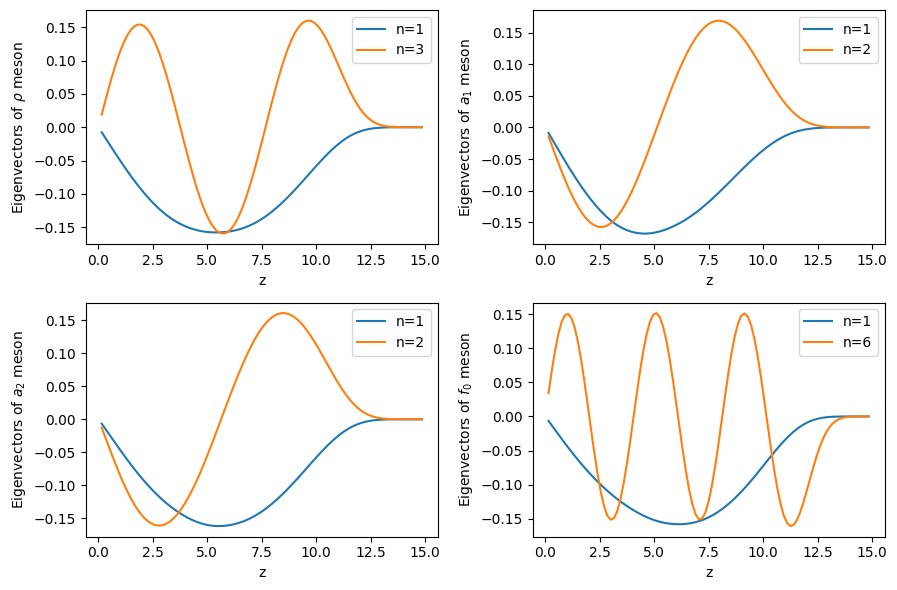

In [8]:
from torch.linalg import eigh

z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L)

diag_elem_rho = 2 + V_rho*dz**2
diag_elem_a1 = 2 + V_a1*dz**2
diag_elem_a2 = 2 + V_a2*dz**2
diag_elem_f0 = 2 + V_f0*dz**2

off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2
mat_a1 = (torch.diag(diag_elem_a1) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2
mat_a2 = (torch.diag(diag_elem_a2) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2
mat_f0 = (torch.diag(diag_elem_f0) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2

eigvals_rho, eigvecs_rho = eigh(mat_rho.cpu())
eigvals_a1, eigvecs_a1 = eigh(mat_a1.cpu())
eigvals_a2, eigvecs_a2 = eigh(mat_a2.cpu())
eigvals_f0, eigvecs_f0 = eigh(mat_f0.cpu())

# plot first 3 eigenvectors of rho meson with error bars
fig, axs = plt.subplots(2, 2, figsize=(9, 6))
axs = axs.flatten()
for i in [0, len(omega_rho)-1]:
    #axs[0].plot(z.cpu().detach().numpy(), rho_eigvec_mean[:, i], label=f'n={i+1}')
    axs[0].plot(z.cpu().detach().numpy(), eigvecs_rho[:, i].cpu().detach().numpy(), label=f'n={i+1}')
    #axs[0].fill_between(z.cpu().detach().numpy(), rho_eigvec_mean[:, i] - rho_eigvec_std[:, i], rho_eigvec_mean[:, i] + rho_eigvec_std[:, i], alpha=0.3)
axs[0].set_xlabel('z')
axs[0].set_ylabel('Eigenvectors of $\\rho$ meson')
axs[0].legend()

for i in [0, len(omega_a1)-1]:
    #axs[1].plot(z.cpu().detach().numpy(), a1_eigvec_mean[:, i], label=f'n={i+1}')
    axs[1].plot(z.cpu().detach().numpy(), eigvecs_a1[:, i].cpu().detach().numpy(), label=f'n={i+1}')
    #axs[1].fill_between(z.cpu().detach().numpy(), a1_eigvec_mean[:, i] - a1_eigvec_std[:, i], a1_eigvec_mean[:, i] + a1_eigvec_std[:, i], alpha=0.3)

axs[1].set_xlabel('z')
axs[1].set_ylabel('Eigenvectors of $a_1$ meson')
axs[1].legend()

for i in [0, len(omega_a2)-1]:
    #axs[2].plot(z.cpu().detach().numpy(), a2_eigvec_mean[:, i], label=f'n={i+1}')
    axs[2].plot(z.cpu().detach().numpy(), eigvecs_a2[:, i].cpu().detach().numpy(), label=f'n={i+1}')
    #axs[2].fill_between(z.cpu().detach().numpy(), a2_eigvec_mean[:, i] - a2_eigvec_std[:, i], a2_eigvec_mean[:, i] + a2_eigvec_std[:, i], alpha=0.3)
axs[2].set_xlabel('z')
axs[2].set_ylabel('Eigenvectors of $a_2$ meson')
axs[2].legend()

for i in [0, len(omega_f0)-1]:
    #axs[3].plot(z.cpu().detach().numpy(), f0_eigvec_mean[:, i], label=f'n={i+1}')
    axs[3].plot(z.cpu().detach().numpy(), eigvecs_f0[:, i].cpu().detach().numpy(), label=f'n={i+1}')
    #axs[3].fill_between(z.cpu().detach().numpy(), f0_eigvec_mean[:, i] - f0_eigvec_std[:, i], f0_eigvec_mean[:, i] + f0_eigvec_std[:, i], alpha=0.3)
axs[3].set_xlabel('z')
axs[3].set_ylabel('Eigenvectors of $f_0$ meson')
axs[3].legend()

plt.tight_layout()
plt.savefig('results/eigenvectors.pdf')
plt.show()




Predicted Pi Masses (GeV):  [       nan 1.741156   1.87939085]


/tmp/ipykernel_1565332/1540846726.py:35: RuntimeWarning: invalid value encountered in sqrt
  mass_pi = np.sqrt(eigvals_pi[:len(omega_pi)]/(L**2))


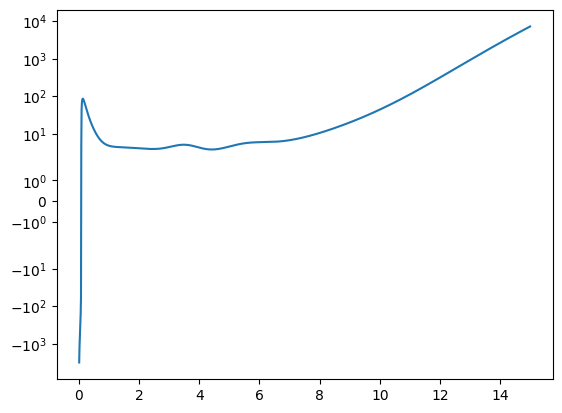

In [17]:
dz = 0.01

z = torch.arange(dz, z_max, dz, device=device, requires_grad=True)

v_z = v_z_fn(z, model_v, theta, L)
dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

A_z = A_z_fn(z, model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, k1, k2)
dB1_dz = dB2_dz + 2*dA_dz

omega_z = 2*dv_dz/v_z - dB2_dz
C_z = g5_sq*exp_2A*v_z**2

d_omega_dz = autograd.grad(omega_z, z, torch.ones_like(omega_z), create_graph=True)[0]

V_pi = omega_z**2/4 - d_omega_dz/2 + C_z

diag_elem_pi = 2 + V_pi*dz**2
off_diag_elem = -1 * torch.ones_like(diag_elem_pi[:-1])

mat_pi = (torch.diag(diag_elem_pi) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2

# robin BC
mat_pi[0,0] = (1 - omega_z[0]*dz/2)/dz**2 + V_pi[0]
mat_pi[0,1] = -1/dz**2

eigvals_pi = torch.linalg.eigvals(mat_pi.cpu())

eigvals_pi = np.sort(eigvals_pi.real.cpu().detach().numpy())
mass_pi = np.sqrt(eigvals_pi[:len(omega_pi)]/(L**2))
print("Predicted Pi Masses (GeV): ", mass_pi)

plt.plot(z.cpu().detach().numpy(), V_pi.cpu().detach().numpy(), label='$V_{\\pi}(z)$')
plt.yscale('symlog')

Predicted Pi Masses (GeV):  [0.16241101 1.74714999 1.88411269]


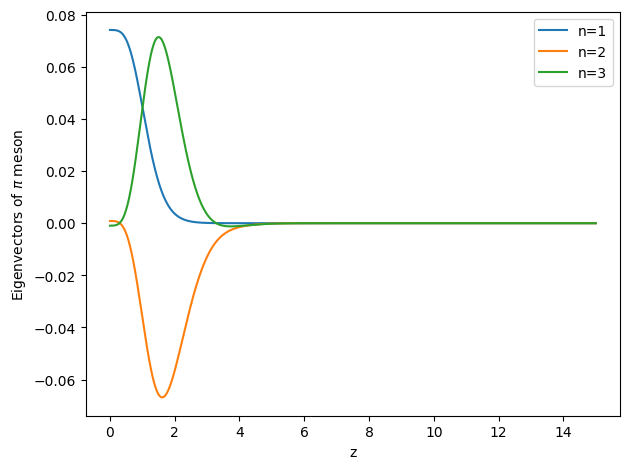

In [ ]:
dz = 0.005

z = torch.arange(dz, z_max, dz, device=device, requires_grad=True)

v_z = v_z_fn(z, model_v, theta, L)
dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

A_z = A_z_fn(z, model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, k1, k2)
dB1_dz = dB2_dz + 2*dA_dz

omega_z = 2*dv_dz/v_z - dB2_dz
C_z = g5_sq*exp_2A*v_z**2

diag_elem_pi = 2/dz**2 + omega_z/dz + C_z
off_diag_elem_pi_minus = -1/dz**2 - omega_z[1:]/dz
off_diag_elem_pi_plus = -1/dz**2*torch.ones_like(off_diag_elem_pi_minus)

mat_pi = (torch.diag(diag_elem_pi) + torch.diag(off_diag_elem_pi_plus, diagonal=1) + torch.diag(off_diag_elem_pi_minus, diagonal=-1))

mat_pi[0,0] = -1/dz**2 + 2/dz**2 + C_z[0]

eigvals_pi, eigvecs_pi = torch.linalg.eig(mat_pi.cpu())

# sort and save the index
sorted_indices = torch.argsort(eigvals_pi.real)
eigvals_pi = eigvals_pi[sorted_indices]
eigvecs_pi = eigvecs_pi[:, sorted_indices]

mass_pi = torch.sqrt(eigvals_pi[:len(omega_pi)].real/(L**2))
print("Predicted Pi Masses (GeV): ", mass_pi.cpu().detach().numpy())

# plot the first 3 eigenvectors of pi meson
for i in range(len(omega_pi)):
    plt.plot(z.cpu().detach().numpy(), eigvecs_pi[:, i].real.cpu().detach().numpy(), label=f'n={i+1}')
plt.xlabel('z')
plt.ylabel('Eigenvectors of $\\pi$ meson')
plt.legend()
plt.tight_layout()
plt.savefig('results/eigenvectors_pi.pdf')
plt.show()

